In [20]:
import os
import re
import subprocess
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer

LOCAL_NLTK_PATHS = [
    os.path.join(os.path.expanduser('~'), 'nltk_data'),
    os.path.join(os.getcwd(), 'nltk_data'),
]
for p in LOCAL_NLTK_PATHS:
    if os.path.isdir(p) and p not in nltk.data.path:
        nltk.data.path.append(p)

FALLBACK_STOPWORDS = {
    'a','an','the','and','or','but','if','then','else','of','in','on','at','to','for','from',
    'is','are','was','were','be','been','being','it','its','this','that','these','those','as',
    'by','with','about','into','over','after','before','between','through','during','without',
    'i','you','he','she','we','they','me','him','her','us','them','my','your','his','their',
    'am','do','does','did','doing','have','has','had','having','not','no','so','than','too',
}


def load_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
        return set(stopwords.words('english'))
    except LookupError:
        pass
    try:
        download_dir = os.path.join(os.path.expanduser('~'), 'nltk_data')
        os.makedirs(download_dir, exist_ok=True)
        ok = nltk.download('stopwords', download_dir=download_dir, quiet=True)
        if ok:
            if download_dir not in nltk.data.path:
                nltk.data.path.append(download_dir)
            return set(stopwords.words('english'))
    except Exception:
        pass
    try:
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
        print('Using sklearn stopwords fallback (NLTK stopwords unavailable).')
        return set(ENGLISH_STOP_WORDS)
    except Exception:
        print('Using minimal built-in stopwords fallback.')
        return set(FALLBACK_STOPWORDS)

DATA_PATH = 'news_cleaned.csv'


PROCESS_MODE = os.environ.get('FNB_PROCESS_MODE', 'max_rows')
MAX_ROWS_NLP = int(os.environ.get('FNB_MAX_ROWS_NLP', '500_000'))
FRACTION_NLP = float(os.environ.get('FNB_FRACTION_NLP', '0.10'))

CHUNK_SIZE = int(os.environ.get('FNB_CHUNK_SIZE', '50_000'))

TEXT_COL_CANDIDATES = ['content', 'text', 'body', 'article', 'title']
LABEL_COL_CANDIDATES = ['type', 'label', 'class', 'category', 'target', 'fake']

URL_COL_CANDIDATES = ['url']
DOMAIN_COL_CANDIDATES = ['domain']
DATE_COL_CANDIDATES = ['scraped_at', 'inserted_at', 'updated_at']

stemmer = PorterStemmer()
_tokenizer = RegexpTokenizer(r"[A-Za-z']+")
_stop_words = load_stopwords()


def get_total_data_rows(csv_path: str) -> int:
    """Fast line-count via wc; assumes one header line."""
    out = subprocess.check_output(['wc', '-l', csv_path]).decode('utf-8').strip().split()[0]
    return max(int(out) - 1, 0)


def pick_first_existing_column(df_columns, candidates):
    for c in candidates:
        if c in df_columns:
            return c
    return None


def normalize_text(text: str) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ''
    text = str(text)
    text = text.lower()

    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)
    text = re.sub(r"[^a-z']+", ' ', text)
    return text


def tokenize(text: str):
    """Tokenize into alpha tokens; designed to be fast and not require punkt."""
    return _tokenizer.tokenize(text)


def stream_sample(csv_path: str, usecols, chunk_size: int, max_rows: int | None = None, fraction: float | None = None):
    """Stream rows from CSV in chunks; stop after max_rows or (fraction * total_rows).

    Uses a robust CSV parsing strategy to survive malformed lines in very large corpora.
    """
    if max_rows is None and fraction is None:
        raise ValueError('Provide max_rows or fraction')

    total_rows = None
    limit_rows = None
    if fraction is not None:
        total_rows = get_total_data_rows(csv_path)
        limit_rows = int(total_rows * fraction)

    base_read_kwargs = dict(
        usecols=usecols,
        chunksize=chunk_size,
        on_bad_lines='skip',
        encoding='utf-8',
        encoding_errors='ignore',
    )

    n_seen = 0

    try:
        iterator = pd.read_csv(csv_path, engine='c', low_memory=True, **base_read_kwargs)
        parser_name = 'c'
    except Exception as e:
        print(f'Falling back to python CSV engine due to parser setup error: {e}')
        iterator = pd.read_csv(csv_path, engine='python', **base_read_kwargs)
        parser_name = 'python'

    try:
        for chunk in iterator:
            if max_rows is not None:
                remaining = max_rows - n_seen
                if remaining <= 0:
                    break
                chunk = chunk.iloc[:remaining]

            yield chunk
            n_seen += len(chunk)

            if limit_rows is not None and n_seen >= limit_rows:
                break
    except pd.errors.ParserError as e:
        if parser_name == 'c':
            print(f'C engine failed while streaming ({e}). Retrying with python engine...')
            n_seen = 0
            iterator = pd.read_csv(csv_path, engine='python', **base_read_kwargs)
            for chunk in iterator:
                if max_rows is not None:
                    remaining = max_rows - n_seen
                    if remaining <= 0:
                        break
                    chunk = chunk.iloc[:remaining]

                yield chunk
                n_seen += len(chunk)

                if limit_rows is not None and n_seen >= limit_rows:
                    break
        else:
            raise


def stopword_filter(tokens):
    return [t for t in tokens if t not in _stop_words]


def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

In [21]:
df_head = pd.read_csv(DATA_PATH, nrows=5)
cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
print('Columns:', cols)

TEXT_COL = pick_first_existing_column(cols, TEXT_COL_CANDIDATES)
LABEL_COL = pick_first_existing_column(cols, LABEL_COL_CANDIDATES)
URL_COL = pick_first_existing_column(cols, URL_COL_CANDIDATES)
DOMAIN_COL = pick_first_existing_column(cols, DOMAIN_COL_CANDIDATES)
DATE_COL = pick_first_existing_column(cols, DATE_COL_CANDIDATES)

print('Detected columns:')
print('  TEXT_COL  =', TEXT_COL)
print('  LABEL_COL =', LABEL_COL)
print('  URL_COL   =', URL_COL)
print('  DOMAIN_COL=', DOMAIN_COL)
print('  DATE_COL  =', DATE_COL)

print('\nHead preview:')
display(df_head.head())

Columns: ['Unnamed: 0', 'id', 'domain', 'type', 'url', 'content', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary', 'source']
Detected columns:
  TEXT_COL  = content
  LABEL_COL = type
  URL_COL   = url
  DOMAIN_COL= domain
  DATE_COL  = scraped_at

Head preview:


,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary,source
0,0,2,express.co.uk,rumor,https://www.express.co.uk/news/science/738402/...,"Life is an illusion, at least on a quantum lev...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Is life an ILLUSION? Researchers prove 'realit...,Sean Martin,NaN,[''],THE UNIVERSE ceases to exist when we are not l...,NaN,NaN,NaN
1,1,6,barenakedislam.com,hate,http://barenakedislam.com/category/donald-trum...,"Unfortunately, he hasn’t yet attacked her for ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Donald Trump,"Linda Rivera, Conrad Calvano, Az Gal, Lincoln ...",NaN,[''],NaN,NaN,NaN,NaN
2,2,7,barenakedislam.com,hate,http://barenakedislam.com/category/donald-trum...,The Los Angeles Police Department has been den...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Donald Trump,"Linda Rivera, Conrad Calvano, Az Gal, Lincoln ...",NaN,[''],NaN,NaN,NaN,NaN
3,3,8,barenakedislam.com,hate,http://barenakedislam.com/2017/12/24/more-winn...,The White House has decided to quietly withdra...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,"MORE WINNING! Israeli intelligence source, DEB...","Cleavis Nowell, Cleavisnowell, Clarence J. Fei...",NaN,[''],NaN,NaN,NaN,NaN
4,4,9,barenakedislam.com,hate,http://barenakedislam.com/2017/12/25/oh-trump-...,“The time has come to cut off the tongues of t...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,"“Oh, Trump, you coward, you just wait, we will...","F.N. Lehner, Don Spilman, Clarence J. Feinour,...",NaN,[''],NaN,NaN,NaN,NaN


Task 1 — Structure, process, and clean

In [22]:
usecols_task1 = [TEXT_COL]

max_rows = MAX_ROWS_NLP if PROCESS_MODE == 'max_rows' else None
fraction = FRACTION_NLP if PROCESS_MODE == 'fraction' else None

vocab_raw = set()
vocab_nostop = set()
vocab_stem = set()

counter_raw = Counter()
counter_nostop = Counter()
counter_stem = Counter()

n_rows_seen = 0

for chunk in stream_sample(DATA_PATH, usecols=usecols_task1, chunk_size=CHUNK_SIZE, max_rows=max_rows, fraction=fraction):
    n_rows_seen += len(chunk)

    texts = chunk[TEXT_COL].fillna('').astype(str).tolist()

    for text in texts:
        norm = normalize_text(text)
        tokens = tokenize(norm)
        if not tokens:
            continue

        vocab_raw.update(tokens)
        counter_raw.update(tokens)

        tokens_ns = stopword_filter(tokens)
        if tokens_ns:
            vocab_nostop.update(tokens_ns)
            counter_nostop.update(tokens_ns)

            tokens_st = stem_tokens(tokens_ns)
            if tokens_st:
                vocab_stem.update(tokens_st)
                counter_stem.update(tokens_st)

print(f'Rows processed: {n_rows_seen:,}')

vocab_raw_size = len(vocab_raw)
vocab_nostop_size = len(vocab_nostop)
vocab_stem_size = len(vocab_stem)

reduction_stop = 1.0 - (vocab_nostop_size / vocab_raw_size if vocab_raw_size else 0.0)
reduction_stem = 1.0 - (vocab_stem_size / vocab_nostop_size if vocab_nostop_size else 0.0)
reduction_total = 1.0 - (vocab_stem_size / vocab_raw_size if vocab_raw_size else 0.0)

print('Vocab size (raw):', vocab_raw_size)
print('Vocab size (no stopwords):', vocab_nostop_size)
print('Vocab size (stemmed):', vocab_stem_size)
print('---')
print(f'Reduction after stopwords: {reduction_stop*100:.2f}%')
print(f'Reduction after stemming (on no-stopwords tokens): {reduction_stem*100:.2f}%')
print(f'Total reduction (raw -> stemmed): {reduction_total*100:.2f}%')

TASK1_RESULTS = {
    'n_rows_seen': n_rows_seen,
    'vocab_raw_size': vocab_raw_size,
    'vocab_nostop_size': vocab_nostop_size,
    'vocab_stem_size': vocab_stem_size,
    'reduction_stop': reduction_stop,
    'reduction_stem': reduction_stem,
    'reduction_total': reduction_total,
}

C engine failed while streaming (Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.
). Retrying with python engine...
Rows processed: 600,000
Vocab size (raw): 662098
Vocab size (no stopwords): 661900
Vocab size (stemmed): 544136
---
Reduction after stopwords: 0.03%
Reduction after stemming (on no-stopwords tokens): 17.79%
Total reduction (raw -> stemmed): 17.82%


Task 2 — Explore the dataset

C engine failed while streaming (Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.
). Retrying with python engine...
Rows processed in Task 2 subset: 600,000

Missing values (subset):
  type: 38,090
  domain: 10
  url: 10
  content: 10
  scraped_at: 10
  inserted_at: 10
  updated_at: 10

Label distribution (subset):
  political: 156,933 (26.16%)
  fake: 115,798 (19.30%)
  conspiracy: 108,635 (18.11%)
  bias: 96,175 (16.03%)
  NA: 38,090 (6.35%)
  rumor: 21,784 (3.63%)
  junksci: 16,622 (2.77%)
  clickbait: 15,344 (2.56%)
  unknown: 11,672 (1.95%)
  unreliable: 7,255 (1.21%)
  satire: 5,454 (0.91%)
  hate: 3,443 (0.57%)
  reliable: 2,795 (0.47%)

Content stats (subset):
  Empty/missing `content` rows: 10
  Avg content length (chars): 3188.4

Signals inside `content` (subset):
  Total URL occurrences inside content: 216,384
  Total numeric substrings inside content: 7,159,843

Signals by label:
  fake: avg_urls_in_content=1.177, avg_numeric_substring

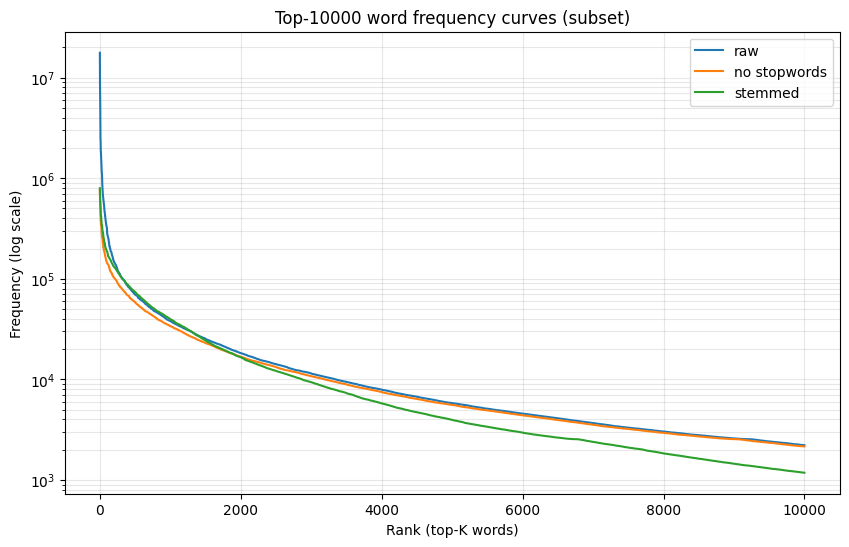

In [23]:
usecols_task2 = [c for c in [TEXT_COL, LABEL_COL, URL_COL, DOMAIN_COL, *[d for d in DATE_COL_CANDIDATES if d]] if c is not None]
all_cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
usecols_task2 = [c for c in usecols_task2 if c in all_cols]

date_cols = [d for d in DATE_COL_CANDIDATES if d in all_cols]

max_rows = MAX_ROWS_NLP if PROCESS_MODE == 'max_rows' else None
fraction = FRACTION_NLP if PROCESS_MODE == 'fraction' else None

label_counts = Counter()
missing_counts = Counter()
content_empty = 0
content_len_sum = 0
url_in_content_total = 0
numeric_substrings_total = 0
label_url_in_content_sum = Counter()
label_numeric_substrings_sum = Counter()
label_len_sum = Counter()
domains_seen = Counter()
domains_empty_content = Counter()
urls_seen = set()
duplicate_urls_in_subset = 0
scraped_dates = set()
inserted_dates = set()
updated_dates = set()

n_rows_seen = 0

date_parse_cache = {}

def count_urls_in_content(series: pd.Series) -> int:
    pattern = r'(?:https?://\S+|www\.\S+)'
    return int(series.fillna('').astype(str).str.count(pattern).sum())


def count_numeric_substrings(series: pd.Series) -> int:
    pattern = r'\d+'
    return int(series.fillna('').astype(str).str.count(pattern).sum())

for chunk in stream_sample(DATA_PATH, usecols=usecols_task2, chunk_size=CHUNK_SIZE, max_rows=max_rows, fraction=fraction):
    n_rows_seen += len(chunk)
    for col in chunk.columns:
        missing_counts[col] += int(chunk[col].isna().sum())
    if LABEL_COL in chunk.columns:
        vc = chunk[LABEL_COL].fillna('NA').astype(str).value_counts()
        for k, v in vc.items():
            label_counts[str(k)] += int(v)

    if TEXT_COL in chunk.columns:
        c = chunk[TEXT_COL]
        content_empty += int(((c.isna()) | (c.astype(str).str.len() == 0)).sum())
        content_len_sum += int(c.fillna('').astype(str).str.len().sum())

        url_in_content_total += count_urls_in_content(c)
        numeric_substrings_total += count_numeric_substrings(c)

        if LABEL_COL in chunk.columns:
            labels = chunk[LABEL_COL].fillna('NA').astype(str)
            url_counts_per_row = c.fillna('').astype(str).str.count(r'(?:https?://\S+|www\.\S+)')
            digit_counts_per_row = c.fillna('').astype(str).str.count(r'\d+')
            lens_per_row = c.fillna('').astype(str).str.len()

            for lab in labels.unique():
                mask = (labels == lab)
                if mask.any():
                    label_url_in_content_sum[lab] += int(url_counts_per_row[mask].sum())
                    label_numeric_substrings_sum[lab] += int(digit_counts_per_row[mask].sum())
                    label_len_sum[lab] += int(lens_per_row[mask].sum())

    if DOMAIN_COL and DOMAIN_COL in chunk.columns:
        domains = chunk[DOMAIN_COL].fillna('NA').astype(str)
        domains_seen.update(domains.value_counts().to_dict())

        if TEXT_COL in chunk.columns:
            c = chunk[TEXT_COL]
            empty_mask = (c.isna()) | (c.astype(str).str.len() == 0)
            if empty_mask.any():
                for dom, cnt in domains[empty_mask].value_counts().items():
                    domains_empty_content[dom] += int(cnt)
    if URL_COL and URL_COL in chunk.columns:
        u = chunk[URL_COL].fillna('NA').astype(str)
        for val in u.tolist():
            if val in urls_seen:
                duplicate_urls_in_subset += 1
            else:
                urls_seen.add(val)

    # Date coverage
    for dcol in date_cols:
        if dcol in chunk.columns:
            parsed = pd.to_datetime(chunk[dcol], errors='coerce', utc=True)
            parsed_days = parsed.dt.date
            parsed_days = parsed_days.dropna().unique()
            if dcol == 'scraped_at':
                scraped_dates.update(parsed_days)
            elif dcol == 'inserted_at':
                inserted_dates.update(parsed_days)
            elif dcol == 'updated_at':
                updated_dates.update(parsed_days)


print(f'Rows processed in Task 2 subset: {n_rows_seen:,}')
print('\nMissing values (subset):')
for col, cnt in missing_counts.most_common():
    print(f'  {col}: {cnt:,}')

print('\nLabel distribution (subset):')
for lab, cnt in label_counts.most_common():
    print(f'  {lab}: {cnt:,} ({cnt / n_rows_seen * 100:.2f}%)')

print('\nContent stats (subset):')
print(f'  Empty/missing `content` rows: {content_empty:,}')
print(f'  Avg content length (chars): {content_len_sum / max(n_rows_seen - content_empty, 1):.1f}')

print('\nSignals inside `content` (subset):')
print(f'  Total URL occurrences inside content: {url_in_content_total:,}')
print(f'  Total numeric substrings inside content: {numeric_substrings_total:,}')

if LABEL_COL and label_counts:
    print('\nSignals by label:')
    for lab in label_counts.keys():
        n_lab = label_counts[lab]
        avg_urls = label_url_in_content_sum[lab] / max(n_lab, 1)
        avg_nums = label_numeric_substrings_sum[lab] / max(n_lab, 1)
        avg_len = label_len_sum[lab] / max(n_lab, 1)
        print(f'  {lab}: avg_urls_in_content={avg_urls:.3f}, avg_numeric_substrings={avg_nums:.3f}, avg_content_len_chars={avg_len:.1f}')

if URL_COL:
    print('\nDuplicate URL detection (within subset):')
    print(f'  Duplicate rows (same URL seen earlier): {duplicate_urls_in_subset:,}')

if DOMAIN_COL:
    print('\nTop domains by frequency (subset):')
    for dom, cnt in domains_seen.most_common(10):
        print(f'  {dom}: {cnt:,}')

print('\nDate coverage (unique days in subset):')

def summarize_days(days_set):
    if not days_set:
        return 'NA'
    ds = sorted(days_set)
    return f'{ds[0]} .. {ds[-1]} (n_days={len(ds)})'

for name, s in [('scraped_at', scraped_dates), ('inserted_at', inserted_dates), ('updated_at', updated_dates)]:
    if name in date_cols:
        print(f'  {name}: {summarize_days(s)}')

TOP_N = 100
print('\nTop words (raw tokens, subset):')
for w, c in counter_raw.most_common(TOP_N):
    print(f'  {w}: {c:,}')

print('\nTop words (after stopword removal, subset):')
for w, c in counter_nostop.most_common(TOP_N):
    print(f'  {w}: {c:,}')

print('\nTop words (after stemming, subset):')
for w, c in counter_stem.most_common(TOP_N):
    print(f'  {w}: {c:,}')

TOP_K_PLOT = 10_000

def plot_topk(counter, title):
    items = counter.most_common(TOP_K_PLOT)
    freqs = [c for _, c in items]
    plt.plot(freqs, label=title)

plt.figure(figsize=(10, 6))
plot_topk(counter_raw, 'raw')
plot_topk(counter_nostop, 'no stopwords')
plot_topk(counter_stem, 'stemmed')
plt.yscale('log')
plt.xlabel('Rank (top-K words)')
plt.ylabel('Frequency (log scale)')
plt.title(f'Top-{TOP_K_PLOT} word frequency curves (subset)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [24]:
print('### Derived observations (based on the processed subset)')

missing_content_rate = content_empty / max(n_rows_seen, 1)
print(f'1) Content availability: empty/missing `content` rate is {missing_content_rate*100:.2f}% over {n_rows_seen:,} rows.')

if label_counts:
    top_labels = label_counts.most_common(3)
    print('2) Label distribution (top classes):')
    for lab, cnt in top_labels:
        print(f'   - {lab}: {cnt:,} ({cnt / max(n_rows_seen,1) * 100:.2f}%)')

    if len(top_labels) >= 2:
        lab0, cnt0 = top_labels[0]
        lab1, cnt1 = top_labels[1]
        print(f'   -> The most common class ({lab0}) is about {cnt0/max(cnt1,1):.2f}x as frequent as the second-most common class ({lab1}).')

if LABEL_COL and label_counts:
    labels = list(label_counts.keys())
    best_urls = sorted(labels, key=lambda x: (label_url_in_content_sum[x] / max(label_counts[x], 1)), reverse=True)[:2]
    best_nums = sorted(labels, key=lambda x: (label_numeric_substrings_sum[x] / max(label_counts[x], 1)), reverse=True)[:2]

    def avg_url(l):
        return label_url_in_content_sum[l] / max(label_counts[l], 1)

    def avg_num(l):
        return label_numeric_substrings_sum[l] / max(label_counts[l], 1)

    if len(best_urls) >= 1:
        l = best_urls[0]
        print(f'3) Per-class “URL-in-content” signal: highest avg URL occurrences is for label `{l}`: {avg_url(l):.3f} per row.')

        if len(best_urls) >= 2:
            l2 = best_urls[1]
            print(f'   -> Runner-up `{l2}`: {avg_url(l2):.3f} per row (difference: {avg_url(l) - avg_url(l2):.3f}).')

    if len(best_nums) >= 1:
        l = best_nums[0]
        print(f'4) Per-class “numeric strings” signal: highest avg numeric substrings is for label `{l}`: {avg_num(l):.3f} per row.')

if URL_COL:
    print(f'5) Duplicate URL artefact (within subset): {duplicate_urls_in_subset:,} rows repeat a URL previously seen in this subset.')

if DOMAIN_COL and domains_seen:
    top_dom, top_dom_cnt = domains_seen.most_common(1)[0]
    print(f'6) Domain concentration: top domain `{top_dom}` accounts for {top_dom_cnt / max(n_rows_seen,1) * 100:.2f}% of rows in the subset.')

if 'scraped_at' in date_cols:
    print(f"7) Date coverage (`scraped_at`): {len(scraped_dates)} unique days over {min(scraped_dates)} .. {max(scraped_dates)}")
if 'inserted_at' in date_cols:
    print(f"   Date coverage (`inserted_at`): {len(inserted_dates)} unique days")
if 'updated_at' in date_cols:
    print(f"   Date coverage (`updated_at`): {len(updated_dates)} unique days")

### Derived observations (based on the processed subset)
1) Content availability: empty/missing `content` rate is 0.00% over 600,000 rows.
2) Label distribution (top classes):
   - political: 156,933 (26.16%)
   - fake: 115,798 (19.30%)
   - conspiracy: 108,635 (18.11%)
   -> The most common class (political) is about 1.36x as frequent as the second-most common class (fake).
3) Per-class “URL-in-content” signal: highest avg URL occurrences is for label `fake`: 1.177 per row.
   -> Runner-up `junksci`: 0.482 per row (difference: 0.695).
4) Per-class “numeric strings” signal: highest avg numeric substrings is for label `hate`: 30.588 per row.
5) Duplicate URL artefact (within subset): 100,009 rows repeat a URL previously seen in this subset.
6) Domain concentration: top domain `beforeitsnews.com` accounts for 18.47% of rows in the subset.
7) Date coverage (`scraped_at`): 1 unique days over 2018-01-25 .. 2018-01-25
   Date coverage (`inserted_at`): 1 unique days
   Date coverage (`updated

Task 3 — Train / validation / test split

In [25]:
from sklearn.model_selection import train_test_split

SPLIT_MAX_ROWS = int(os.environ.get('FNB_SPLIT_MAX_ROWS', '600000'))
RANDOM_STATE = int(os.environ.get('FNB_RANDOM_STATE', '42'))

usecols_split = [TEXT_COL]
if LABEL_COL is not None:
    usecols_split.append(LABEL_COL)

max_rows = SPLIT_MAX_ROWS
fraction = None
if PROCESS_MODE == 'fraction':
    fraction = FRACTION_NLP

chunks = []
n_rows_seen = 0
for chunk in stream_sample(DATA_PATH, usecols=usecols_split, chunk_size=CHUNK_SIZE, max_rows=max_rows, fraction=None):
    chunks.append(chunk)
    n_rows_seen += len(chunk)

df_sample = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=usecols_split)

if LABEL_COL and LABEL_COL in df_sample.columns:
    df_sample = df_sample.dropna(subset=[TEXT_COL, LABEL_COL])
else:
    df_sample = df_sample.dropna(subset=[TEXT_COL])
empty_mask = df_sample[TEXT_COL].astype(str).str.len() == 0
if empty_mask.any():
    df_sample = df_sample.loc[~empty_mask].copy()

CLEAN_COL = 'content_clean_stem'

def clean_content_for_model(text: str) -> str:
    norm = normalize_text(text)
    tokens = tokenize(norm)
    tokens = stopword_filter(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)
df_sample[CLEAN_COL] = df_sample[TEXT_COL].fillna('').astype(str).map(clean_content_for_model)

clean_empty = df_sample[CLEAN_COL].astype(str).str.len() == 0
if clean_empty.any():
    df_sample = df_sample.loc[~clean_empty].copy()

if TEXT_COL in df_sample.columns:
    df_sample = df_sample.drop(columns=[TEXT_COL])

print(f'Split input size (rows): {len(df_sample):,}')

if LABEL_COL and LABEL_COL in df_sample.columns:
    strat = df_sample[LABEL_COL].astype(str)
else:
    strat = None

train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=strat if strat is not None else None,
)

if LABEL_COL and LABEL_COL in temp_df.columns:
    strat_temp = temp_df[LABEL_COL].astype(str)
else:
    strat_temp = None

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=strat_temp if strat_temp is not None else None,
)

print('Split sizes:')
print('  train:', f"{len(train_df):,}", 'rows')
print('  val  :', f"{len(val_df):,}", 'rows')
print('  test :', f"{len(test_df):,}", 'rows')

if LABEL_COL and LABEL_COL in df_sample.columns:
    print('\nLabel distribution:')
    for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
        vc = d[LABEL_COL].astype(str).value_counts(normalize=True)
        print(f'  {name}:')
        for k, v in vc.items():
            print(f'    - {k}: {v*100:.2f}%')

OUT_DIR = os.path.join('dataset', 'splits_sample')
os.makedirs(OUT_DIR, exist_ok=True)

train_path = os.path.join(OUT_DIR, 'train.csv')
val_path = os.path.join(OUT_DIR, 'val.csv')
test_path = os.path.join(OUT_DIR, 'test.csv')

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print('\nSaved:')
print('  ', train_path)
print('  ', val_path)
print('  ', test_path)

C engine failed while streaming (Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.
). Retrying with python engine...
Split input size (rows): 656,762
Split sizes:
  train: 525,409 rows
  val  : 65,676 rows
  test : 65,677 rows

Label distribution:
  train:
    - political: 30.00%
    - fake: 18.74%
    - bias: 17.90%
    - conspiracy: 16.83%
    - rumor: 4.12%
    - unknown: 3.01%
    - clickbait: 2.70%
    - junksci: 2.55%
    - satire: 2.01%
    - unreliable: 1.16%
    - hate: 0.54%
    - reliable: 0.45%
  val:
    - political: 30.00%
    - fake: 18.74%
    - bias: 17.90%
    - conspiracy: 16.83%
    - rumor: 4.12%
    - unknown: 3.01%
    - clickbait: 2.70%
    - junksci: 2.55%
    - satire: 2.01%
    - unreliable: 1.16%
    - hate: 0.54%
    - reliable: 0.45%
  test:
    - political: 30.00%
    - fake: 18.74%
    - bias: 17.90%
    - conspiracy: 16.83%
    - rumor: 4.12%
    - unknown: 3.01%
    - clickbait: 2.70%
    - junksci: 2.55%
    - sat